# Predicting Heart Disease using Machine Learning

This notebook will introduce some machine learning and data science concepts by exploring the problem of heart disease classification

## What is classification?

Classification invloves deciding whether a sample is part of one class or another (**single-class classification**. If there are multiple classes, it's refered to as **multi-class classification**

## Learning Objectives

* **Exploratory Data Analysis (EDA)**
* **Model training**
* **Model Evaluation**
* **Model Comparison**
* **Model fine-tuning**
* **Feature importance**
* **Cross-validation**
* **Reporting what we've found**

## Problem Definition
In our case, the problem we will be expoloring is binary classifciation (a sample can only be on e of two things).

$\therefore$ in a statement:
> Given clinical parameters about a patient, can we predict whther or not htey have heart disease?

## Features

A data dictionary describes the data you're dealing with. Not all datasets come with them so this is where you may have to do your research or ask a subject matter expert (someone who knows about the data) for more.

The following are the features we'll use to predict our target variable (heart disease or no heart disease).

- **age** - age in years
- **sex** - (1 = male; 0 = female)
- **cp** - chest pain type
    0. Typical angina: chest pain related decrease blood supply to the heart
    1. Atypical angina: chest pain not related to heart
    2. Non-anginal pain: typically esophageal spasms (non heart related)
    3. Asymptomatic: chest pain not showing signs of disease
- **trestbps** - resting blood pressure (in mm Hg on admission to the hospital) anything above 130-140 is typically cause for concern.
- **chol** - serum cholestoral in mg/dl
    serum = LDL + HDL + .2 * triglycerides
    above 200 is cause for concern
- **fbs** - (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)
    '>126' mg/dL signals diabetes
- **restecg** - resting electrocardiographic results
    0. Nothing to note
    1. ST-T Wave abnormality
        can range from mild symptoms to severe problems
        signals non-normal heart beat
    2. Possible or definite left ventricular hypertrophy
        Enlarged heart's main pumping chamber
- **thalach** - maximum heart rate achieved
- **exang** - exercise induced angina (1 = yes; 0 = no)
- **oldpeak** - ST depression induced by exercise relative to rest
    looks at stress of heart during excercise
    unhealthy heart will stress more
- **slope** - the slope of the peak exercise ST segment
    0. Upsloping: better heart rate with excercise (uncommon)
    1. Flatsloping: minimal change (typical healthy heart)
    2. Downslopins: signs of unhealthy heart
- **ca** - number of major vessels (0-3) colored by flourosopy
    colored vessel means the doctor can see the blood passing through
    the more blood movement the better (no clots)
- **thal** - thalium stress result
  
    1,3. normal
    6. fixed defect: used to be defect but ok now
    7. reversable defect: no proper blood movement when excercising
- **target** - have disease or not (1=yes, 0=no) (= the predicted attribute)

Note: No personal identifiable information (PPI) can be found in the dataset.

It's a good idea to save these to a Python dictionary or in an external file, so we can look at them later without coming back here.

## Machine Learning Approach

### Preparing the tools

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Models from Scikit-Learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

# Beautification
from utils.dracula_colors import Dracula
dracula = Dracula()

Loaded Dracula Color.
	Available colors: background, current_line, foreground, comment, cyan, green, orange, pink, purple, red, yellow


### Load Data

In [2]:
df = pd.read_csv("./data/heart-disease.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


### EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### Heart Disease Frequency according to Sex

In [5]:
df['sex'].replace({0 : "Female", 1: "Male"}).value_counts()

sex
Male      207
Female     96
Name: count, dtype: int64

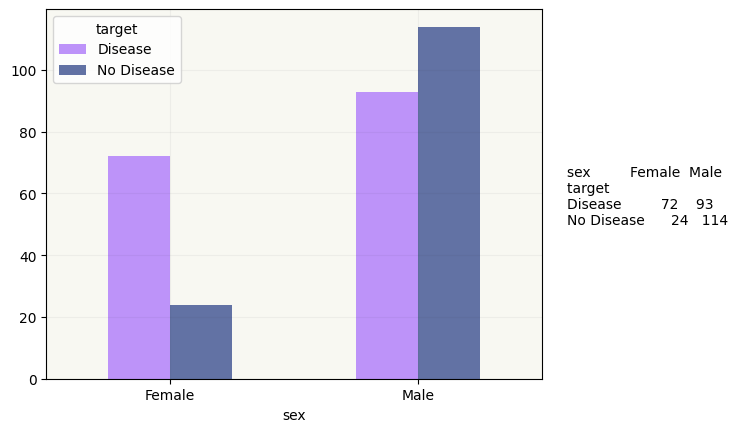

In [115]:
# Compare target with sex column
target_vs_sex = pd.crosstab(df['target'].replace({0 : "No Disease", 1 : "Disease"}), df['sex'].replace({0 : "Female", 1: "Male"}))
target_vs_sex.T.plot(kind='bar', color=[dracula.purple, dracula.comment])
plt.text(1.6, 50, target_vs_sex.__repr__())
plt.xticks(rotation=0)
plt.gca().set_facecolor(dracula.foreground)
plt.grid(color=dracula.background, alpha=0.05)
plt.show()

**Observation**: So we can clearly see that, if someone is a female she has a higher chance of having a heart disease, as the data suggests: 72 out of 96 Females have heart disease.

If we see the ratio of Disease to Gender here's the result:

In [7]:
(target_vs_sex / df['sex'].replace({0 : "Female", 1: "Male"}).value_counts()) * 100

sex,Female,Male
target,,
Disease,75.0,44.927536
No Disease,25.0,55.072464


### Age vs. Max Heart Rate for Heart Disease


|Variable|DataType|Description|
|--------|--------|-----------|
|**age**|$number$|age in years|
|**thalach**|$number$|maximum heart rate achieved |
|**target**|$bool$| $\begin{cases}0 &\rightarrow \text{ No Heart Disease}, \\1 &\rightarrow \text{ Heart Disease}\end{cases}$ |


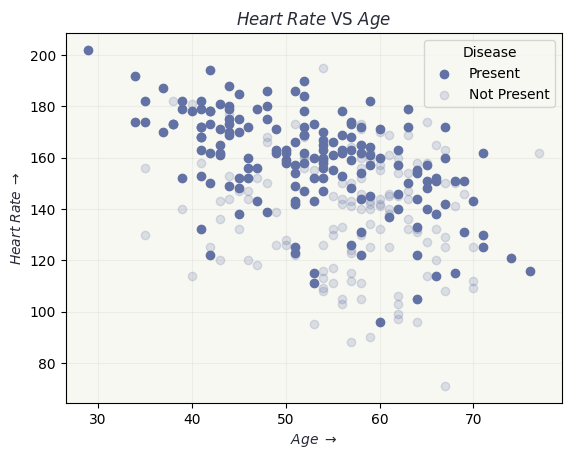

In [68]:
# Scatter plot | Heart Rate vs Age
plt.scatter(x=df.age[df.target == 1], y=df.thalach[df.target==1], color=dracula.comment, label='Present')
plt.scatter(x=df.age[df.target == 0], y=df.thalach[df.target==0], color=dracula.comment, label='Not Present', alpha=0.20)
plt.xlabel(r'$Age\; \rightarrow$', color=dracula.background)
plt.ylabel(r'$Heart\; Rate\; \rightarrow$', color=dracula.background)
plt.title(r"$Heart\; Rate$ VS $Age$", color=dracula.background)
plt.legend(title='Disease', facecolor=dracula.foreground)
plt.gca().set_facecolor(dracula.foreground)
plt.grid(color=dracula.background, alpha=0.05)
plt.show()
# same thing in seaborn ->
# sns.scatterplot(data=df, x='age', y='thalach', hue='target')

**Observation**: As age increases, Heart Rate decreases.

In other words, as a person grows old, heart rate tends to go down whether or not they have heart disease or not.

#### Distribution of Age

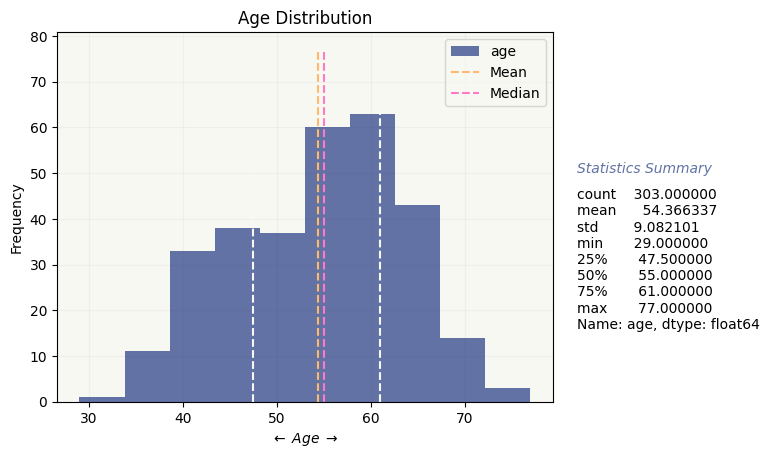

In [64]:
df.age.plot(kind='hist', color='#6272a4')
age_stat = df.describe().age
plt.vlines('mean', 0, 'max', linestyle='--', colors=dracula.orange, data=age_stat, label='Mean')
plt.vlines('50%', 0, 'max', linestyle='--', colors=dracula.pink, data=age_stat, label='Median')
plt.vlines('25%', 0, 'max', linestyle='--', colors=dracula.foreground, data=age_stat)
plt.vlines('75%', 0, 'max', linestyle='--', colors=dracula.foreground, data=age_stat)
plt.text(82, 50, "Statistics Summary", fontstyle='italic', color=dracula.comment)
plt.text(82, 16, age_stat.__str__(), fontstyle='normal')
plt.title("Age Distribution")
plt.xlabel(r"$\leftarrow \;Age\;\rightarrow$")
plt.legend(facecolor=dracula.foreground)
plt.gca().set_facecolor("#f8f8f2")
plt.grid(color="#44475a", alpha=0.05)
plt.show()

**Observation**: Age can be assumed Normally distributed as Mean $54.37$ is close to the Median of $55.00$ with a slight left skewness